In [1]:
print("Hello NeoVitalPulse")

Hello NeoVitalPulse


In [2]:
import pandas as pd
import numpy as np
import sklearn

print("Environment working correctly ✅")

Environment working correctly ✅


In [3]:
import pandas as pd

df = pd.read_csv('../data/heart.csv')

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info

<bound method DataFrame.info of       age     sex  chest_pain_type  resting_blood_pressure  cholestoral  \
0      52    Male   Typical angina                     125          212   
1      53    Male   Typical angina                     140          203   
2      70    Male   Typical angina                     145          174   
3      61    Male   Typical angina                     148          203   
4      62  Female   Typical angina                     138          294   
...   ...     ...              ...                     ...          ...   
1020   59    Male  Atypical angina                     140          221   
1021   60    Male   Typical angina                     125          258   
1022   47    Male   Typical angina                     110          275   
1023   50  Female   Typical angina                     110          254   
1024   54    Male   Typical angina                     120          188   

         fasting_blood_sugar               rest_ecg  Max_heart_rate

In [6]:
df.isnull().sum()

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

In [7]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

Matplotlib is building the font cache; this may take a moment.


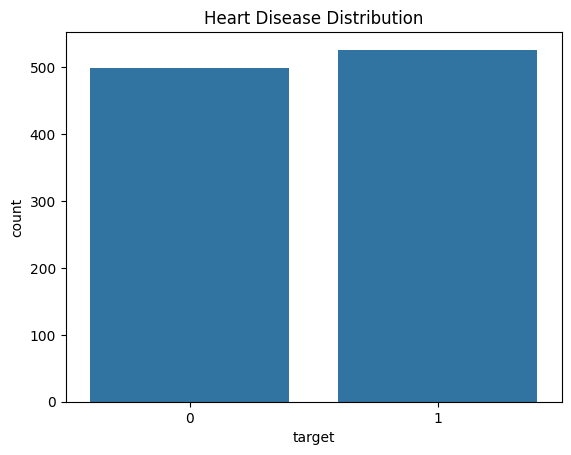

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

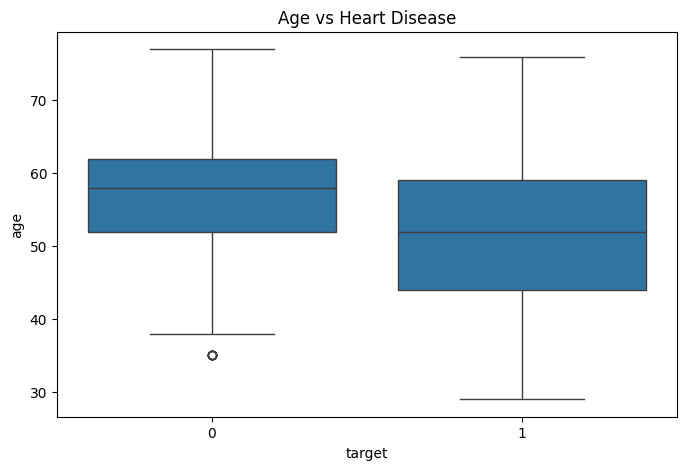

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

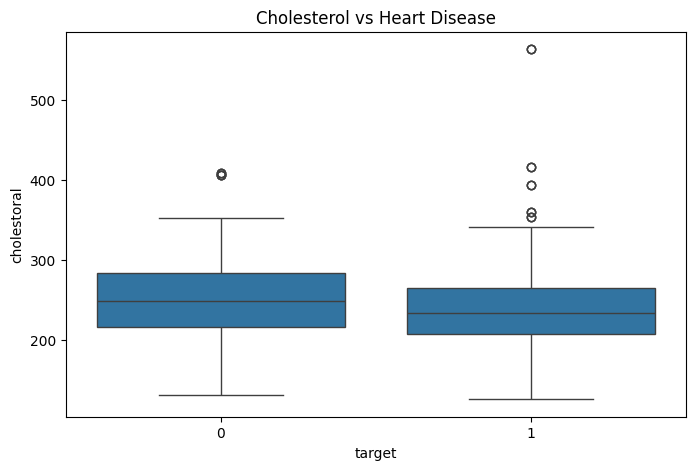

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='cholestoral', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

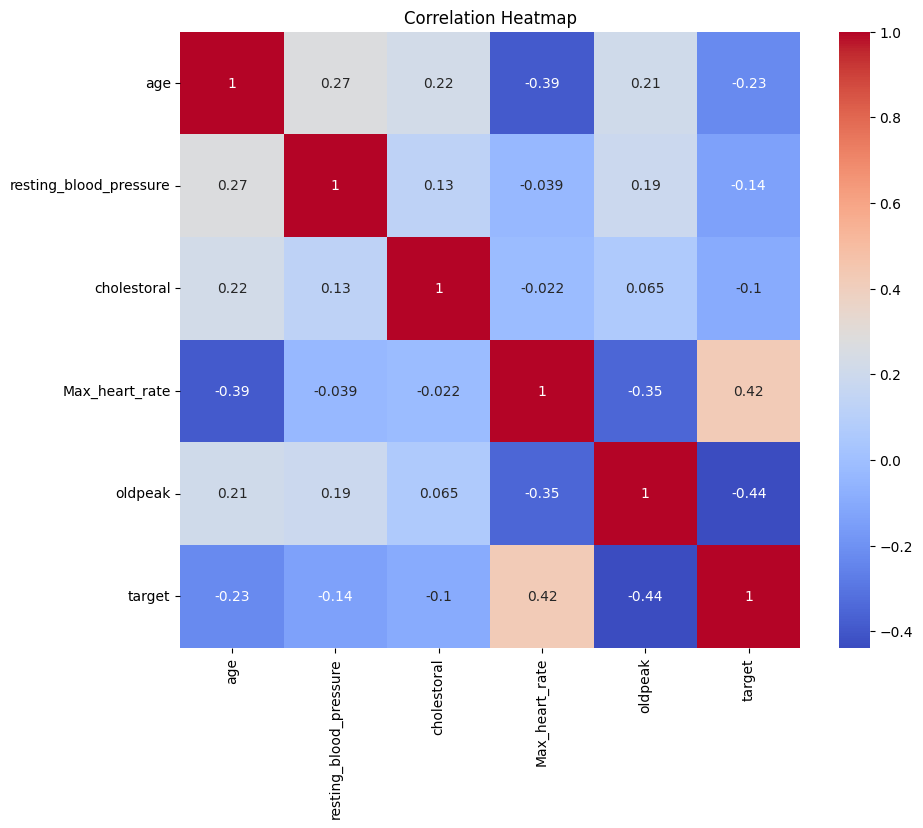

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
df.select_dtypes(include='object').columns

Index(['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg',
       'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy',
       'thalassemia'],
      dtype='object')

In [14]:
df['sex'].unique()

array(['Male', 'Female'], dtype=object)

In [15]:
df['chest_pain_type'].unique()

array(['Typical angina', 'Atypical angina', 'Non-anginal pain',
       'Asymptomatic'], dtype=object)

In [16]:
df['fasting_blood_sugar'].unique()

array(['Lower than 120 mg/ml', 'Greater than 120 mg/ml'], dtype=object)

In [17]:
df['rest_ecg'].unique()

array(['ST-T wave abnormality', 'Normal', 'Left ventricular hypertrophy'],
      dtype=object)

In [18]:
df['exercise_induced_angina'].unique()

array(['No', 'Yes'], dtype=object)

In [19]:
df['slope'].unique()

array(['Downsloping', 'Upsloping', 'Flat'], dtype=object)

In [20]:
df['vessels_colored_by_flourosopy'].unique()

array(['Two', 'Zero', 'One', 'Three', 'Four'], dtype=object)

In [21]:
df['thalassemia'].unique()

array(['Reversable Defect', 'Fixed Defect', 'Normal', 'No'], dtype=object)

In [22]:
df_processed = df.copy()

In [23]:
df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

In [24]:
df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

In [25]:
df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

In [26]:
df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

In [27]:
df_processed.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,Typical angina,125,212,0,ST-T wave abnormality,168,0,1.0,Downsloping,2,Reversable Defect,0
1,53,1,Typical angina,140,203,1,Normal,155,1,3.1,Upsloping,0,Reversable Defect,0
2,70,1,Typical angina,145,174,0,ST-T wave abnormality,125,1,2.6,Upsloping,0,Reversable Defect,0
3,61,1,Typical angina,148,203,0,ST-T wave abnormality,161,0,0.0,Downsloping,1,Reversable Defect,0
4,62,0,Typical angina,138,294,1,ST-T wave abnormality,106,0,1.9,Flat,3,Fixed Defect,0


In [28]:
pd.get_dummies()

TypeError: get_dummies() missing 1 required positional argument: 'data'

In [29]:
df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

In [30]:
df_processed.shape

(1025, 20)

In [31]:
df_processed.shape

(1025, 20)

In [32]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               1025 non-null   int64  
 1   sex                               1025 non-null   int64  
 2   resting_blood_pressure            1025 non-null   int64  
 3   cholestoral                       1025 non-null   int64  
 4   fasting_blood_sugar               1025 non-null   int64  
 5   Max_heart_rate                    1025 non-null   int64  
 6   exercise_induced_angina           1025 non-null   int64  
 7   oldpeak                           1025 non-null   float64
 8   vessels_colored_by_flourosopy     1025 non-null   int64  
 9   target                            1025 non-null   int64  
 10  chest_pain_type_Atypical angina   1025 non-null   bool   
 11  chest_pain_type_Non-anginal pain  1025 non-null   bool   
 12  chest_

In [33]:
X = df_processed.drop('target', axis=1)
y = df_processed['target']

In [34]:
print(X.shape)
print(y.shape)

(1025, 19)
(1025,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [36]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (820, 19)
X_test: (205, 19)
y_train: (820,)
y_test: (205,)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(820, 19)
(205, 19)


In [39]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred_log = log_model.predict(X_test_scaled)

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8048780487804879

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.75      0.79       102
           1       0.77      0.86      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205


Confusion Matrix:
 [[76 26]
 [14 89]]


In [43]:
Accuracy: 0.8048780487804879

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.75      0.79       102
           1       0.77      0.86      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205


Confusion Matrix:
 [[76 26]
 [14 89]]


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 6)

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205


Confusion Matrix:
 [[102   0]
 [  3 100]]


In [45]:
df.duplicated().sum()

723

In [46]:
df_no_duplicates = df.drop_duplicates()

In [47]:
df_no_duplicates.shape

(302, 14)

In [48]:
df = df_no_duplicates.copy()

In [49]:
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

In [50]:
df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

In [51]:
X = df_processed.drop('target', axis=1)
y = df_processed['target']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


Accuracy: 0.7377049180327869

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.66      0.72        32
           1       0.69      0.83      0.75        29

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61


Confusion Matrix:
 [[21 11]
 [ 5 24]]


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8524590163934426

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.85        32
           1       0.81      0.90      0.85        29

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61


Confusion Matrix:
 [[26  6]
 [ 3 26]]


In [55]:
from sklearn.metrics import roc_auc_score

y_pred_prob_rf = rf_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_pred_prob_rf)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.8663793103448276


In [56]:
import pandas as pd
import numpy as np

# Get importance values
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
11,chest_pain_type_Typical angina,0.119049
7,oldpeak,0.115802
5,Max_heart_rate,0.114205
8,vessels_colored_by_flourosopy,0.100531
18,thalassemia_Reversable Defect,0.085779
0,age,0.080958
3,cholestoral,0.072568
2,resting_blood_pressure,0.071975
6,exercise_induced_angina,0.059915
1,sex,0.041997


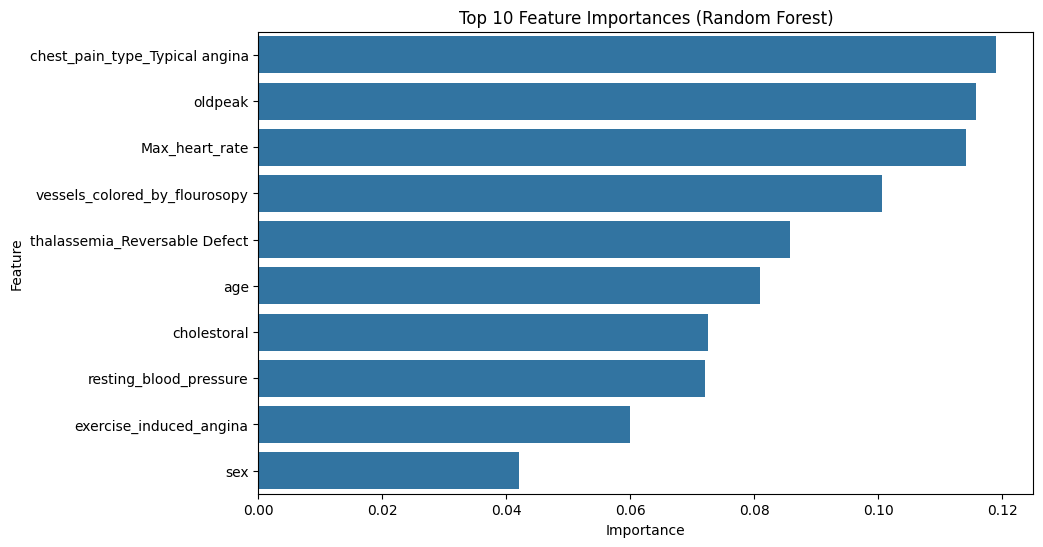

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(10)
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation scores: [0.85245902 0.78688525 0.93333333 0.75       0.8       ]
Mean CV Accuracy: 0.8245355191256831
Standard Deviation: 0.06354803609864262


In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation Score: 0.8475956284153006


In [60]:
best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X, y)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [61]:
import joblib

joblib.dump(best_rf, "../models/heart_rf_model.pkl")

['../models/heart_rf_model.pkl']

In [62]:
NeoVitalPulse/models/

SyntaxError: invalid syntax (1740042702.py, line 1)

In [63]:
sample = X.iloc[0:1]  # Take one patient

probability = best_rf.predict_proba(sample)[0][1]

print("Predicted Probability of Heart Disease:", probability)

Predicted Probability of Heart Disease: 0.25854203829425626


In [64]:
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Moderate Risk"
    else:
        return "High Risk"

In [65]:
print("Risk Level:", risk_category(probability))

Risk Level: Low Risk


In [66]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [67]:
from src.predict import predict_heart_disease

FileNotFoundError: [Errno 2] No such file or directory: 'models/heart_rf_model.pkl'

In [68]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [69]:
from src.predict import predict_heart_disease

In [70]:
sample_input = X.iloc[0].to_dict()
result = predict_heart_disease(sample_input)
print(result)

{'probability': 0.25854203829425626, 'risk_level': 'Low Risk'}


In [1]:
import shap
print(shap.__version__)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\arpit\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [1]:
import sys
print(sys.executable)

C:\Users\arpit\anaconda3\envs\neovitalpulse_v2\python.exe


In [2]:
import numpy
import shap

print(numpy.__version__)
print(shap.__version__)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


1.24.3
0.44.1


In [3]:
import shap

explainer = shap.TreeExplainer(best_rf)

NameError: name 'best_rf' is not defined

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [5]:
import joblib

model_path = os.path.abspath("../models/heart_rf_model.pkl")
best_rf = joblib.load(model_path)

print("Model Loaded Successfully")

Trying to unpickle estimator DecisionTreeClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


Model Loaded Successfully


Trying to unpickle estimator RandomForestClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


In [6]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# Apply same preprocessing steps again

In [7]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values[1], X)

NameError: name 'X' is not defined

In [8]:
import pandas as pd

# 1️⃣ Load data
df = pd.read_csv("../data/heart.csv")

# 2️⃣ Remove duplicates
df = df.drop_duplicates()

# 3️⃣ Copy for processing
df_processed = df.copy()

# 4️⃣ Binary mappings
df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

# 5️⃣ One-hot encoding
df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

# 6️⃣ Define X and y
X = df_processed.drop('target', axis=1)
y = df_processed['target']

print("X shape:", X.shape)

X shape: (302, 19)


In [9]:
import joblib
best_rf = joblib.load("../models/heart_rf_model.pkl")

Trying to unpickle estimator DecisionTreeClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


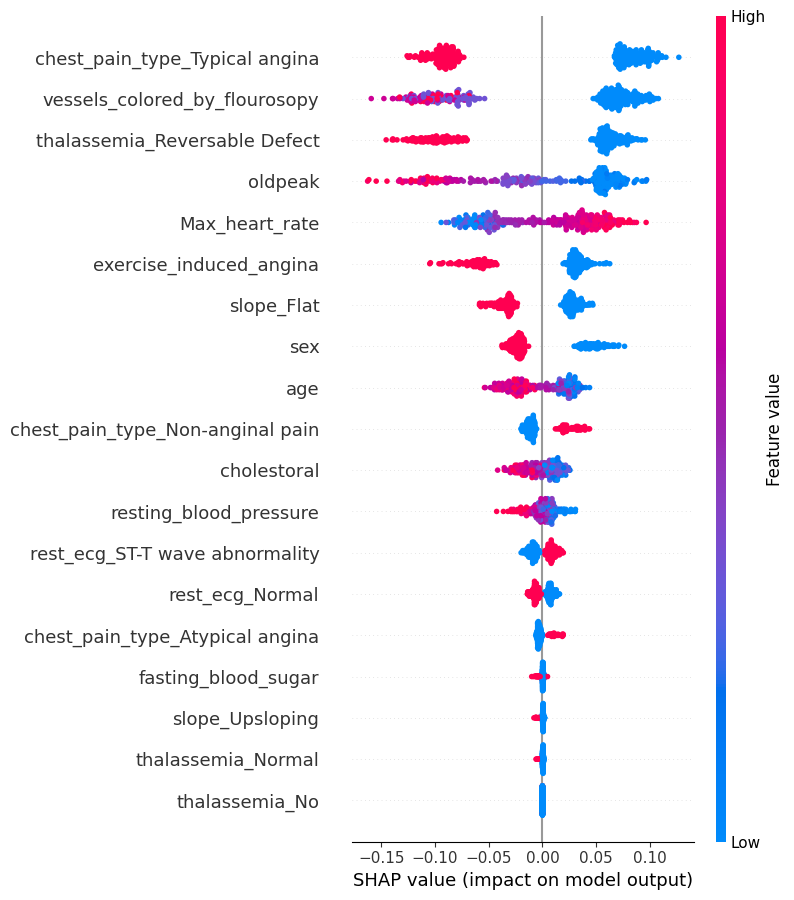

In [10]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values[1], X)

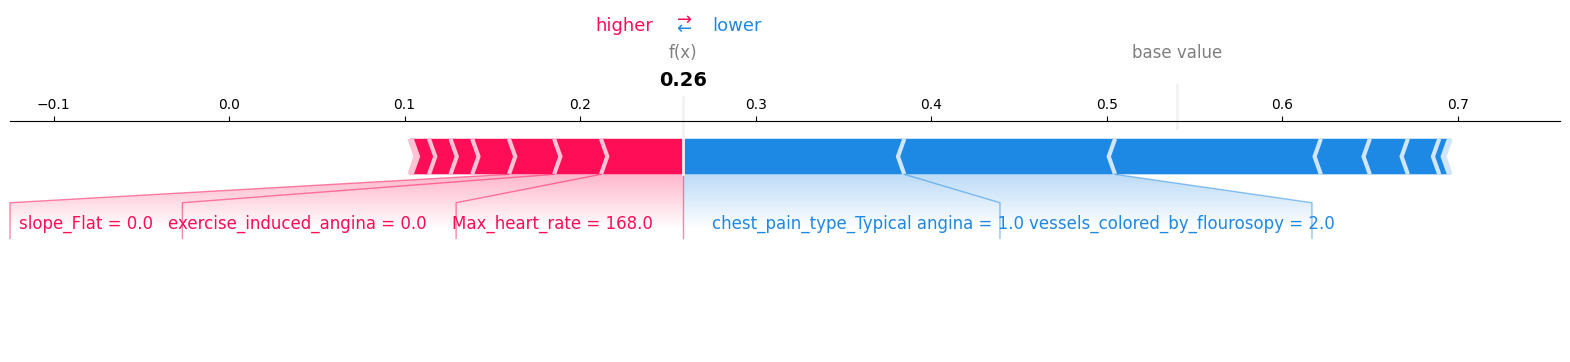

In [11]:
sample = X.iloc[0]

shap.force_plot(
    explainer.expected_value[1],
    shap_values[1][0],
    sample,
    matplotlib=True
)

In [12]:
sample


age                                    52
sex                                     1
resting_blood_pressure                125
cholestoral                           212
fasting_blood_sugar                     0
Max_heart_rate                        168
exercise_induced_angina                 0
oldpeak                               1.0
vessels_colored_by_flourosopy           2
chest_pain_type_Atypical angina     False
chest_pain_type_Non-anginal pain    False
chest_pain_type_Typical angina       True
rest_ecg_Normal                     False
rest_ecg_ST-T wave abnormality       True
slope_Flat                          False
slope_Upsloping                     False
thalassemia_No                      False
thalassemia_Normal                  False
thalassemia_Reversable Defect        True
Name: 0, dtype: object

In [13]:
from src.predict import predict_heart_disease

sample_input = X.iloc[0].to_dict()

result = predict_heart_disease(sample_input)

print(result)

Trying to unpickle estimator DecisionTreeClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
Trying to unpickle estimator RandomForestClassifier from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


AttributeError: 'DecisionTreeClassifier' object has no attribute 'monotonic_cst'

In [14]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier

# =============================
# LOAD + CLEAN DATA
# =============================
df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# =============================
# PREPROCESSING
# =============================
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

X = df_processed.drop('target', axis=1)
y = df_processed['target']

# =============================
# TRAIN FINAL TUNED MODEL
# =============================
best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X, y)

# =============================
# SAVE MODEL
# =============================
joblib.dump(best_rf, "../models/heart_rf_model.pkl")

print("✅ Model trained and saved successfully.")

✅ Model trained and saved successfully.


In [15]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.predict import predict_heart_disease

# Recreate X once for testing
df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# Apply same preprocessing again here for testing
# (same steps as training)

sample_input = X.iloc[0].to_dict()

result = predict_heart_disease(sample_input)

print(result)

AttributeError: 'DecisionTreeClassifier' object has no attribute 'monotonic_cst'

In [16]:
from sklearn.ensemble import RandomForestClassifier
import joblib

best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X, y)

joblib.dump(best_rf, "../models/heart_rf_model.pkl")

print("✅ Model re-trained and saved with sklearn 1.5.1")

✅ Model re-trained and saved with sklearn 1.5.1


In [1]:
from src.predict import predict_heart_disease

sample_input = X.iloc[0].to_dict()
result = predict_heart_disease(sample_input)

print(result)

ModuleNotFoundError: No module named 'src'

In [2]:
import sys
import os

# Add project root directory
sys.path.append(os.path.abspath(".."))

print("Project root added to path")

Project root added to path


In [3]:
from src.predict import predict_heart_disease

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [4]:
sample_input = X.iloc[0].to_dict()
result = predict_heart_disease(sample_input)
print(result)

NameError: name 'X' is not defined

In [5]:
import pandas as pd

# Load and clean data
df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# Preprocessing
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

X = df_processed.drop('target', axis=1)

print("X shape:", X.shape)

X shape: (302, 19)


In [6]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.predict import predict_heart_disease

In [7]:
sample_input = X.iloc[0].to_dict()

result = predict_heart_disease(sample_input)

print(result)

{'probability': 0.25854203829425626, 'risk_level': 'Low Risk', 'top_risk_factors': ['Max_heart_rate', 'exercise_induced_angina', 'slope_Flat'], 'top_protective_factors': ['chest_pain_type_Typical angina', 'vessels_colored_by_flourosopy', 'thalassemia_Reversable Defect']}


In [1]:
import sklearn
print(sklearn.__version__)

1.5.1


In [2]:
import json

feature_list = list(X.columns)

with open("../models/feature_columns.json", "w") as f:
    json.dump(feature_list, f)

print("Feature list saved.")

NameError: name 'X' is not defined

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# Preprocessing
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

X = df_processed.drop('target', axis=1)
y = df_processed['target']

print("X shape:", X.shape)

X shape: (302, 19)


In [4]:
import json

feature_list = list(X.columns)

with open("../models/feature_columns.json", "w") as f:
    json.dump(feature_list, f)

print("Feature list saved successfully.")

Feature list saved successfully.


In [5]:
from src.predict import predict_heart_disease

raw_input = {
    "age": 52,
    "sex": "Male",
    "chest_pain_type": "Typical angina",
    "resting_blood_pressure": 125,
    "cholestoral": 212,
    "fasting_blood_sugar": "Lower than 120 mg/ml",
    "rest_ecg": "ST-T wave abnormality",
    "Max_heart_rate": 168,
    "exercise_induced_angina": "No",
    "oldpeak": 1.0,
    "slope": "Downsloping",
    "vessels_colored_by_flourosopy": "Two",
    "thalassemia": "Reversable Defect"
}

result = predict_heart_disease(raw_input)

print(result)

ModuleNotFoundError: No module named 'src'

In [6]:
import sys
import os

# Move one level up (from notebooks → project root)
sys.path.append(os.path.abspath(".."))

print("Project root added successfully")

Project root added successfully


In [7]:
from src.predict import predict_heart_disease

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [8]:
raw_input = {
    "age": 52,
    "sex": "Male",
    "chest_pain_type": "Typical angina",
    "resting_blood_pressure": 125,
    "cholestoral": 212,
    "fasting_blood_sugar": "Lower than 120 mg/ml",
    "rest_ecg": "ST-T wave abnormality",
    "Max_heart_rate": 168,
    "exercise_induced_angina": "No",
    "oldpeak": 1.0,
    "slope": "Downsloping",
    "vessels_colored_by_flourosopy": "Two",
    "thalassemia": "Reversable Defect"
}

result = predict_heart_disease(raw_input)

print(result)

{'probability': 0.6905025803689523, 'risk_level': 'Moderate Risk', 'top_risk_factors': ['chest_pain_type_Typical angina', 'thalassemia_Reversable Defect', 'Max_heart_rate'], 'top_protective_factors': ['vessels_colored_by_flourosopy', 'sex', 'chest_pain_type_Non-anginal pain']}


In [1]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

NameError: name 'best_rf' is not defined

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/heart.csv")
df = df.drop_duplicates()

# Preprocessing
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

df_processed = pd.get_dummies(
    df_processed,
    columns=[
        'chest_pain_type',
        'rest_ecg',
        'slope',
        'thalassemia'
    ],
    drop_first=True
)

X = df_processed.drop('target', axis=1)
y = df_processed['target']

print("X shape:", X.shape)

X shape: (302, 19)


In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

NameError: name 'best_rf' is not defined

In [4]:
from sklearn.ensemble import RandomForestClassifier
import joblib

best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X, y)

joblib.dump(best_rf, "../models/heart_rf_model.pkl")

print("✅ Model re-trained and saved with sklearn 1.5.1")

✅ Model re-trained and saved with sklearn 1.5.1


In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

NameError: name 'X_test' is not defined

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load processed dataset (after encoding)
df = pd.read_csv("your_processed_file.csv")  # or re-run encoding steps

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

FileNotFoundError: [Errno 2] No such file or directory: 'your_processed_file.csv'

In [7]:
import pandas as pd

df = pd.read_csv("../data/heart.csv")  # adjust path if needed
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [8]:
df_processed = df.copy()

df_processed['sex'] = df_processed['sex'].map({'Male': 1, 'Female': 0})

df_processed['fasting_blood_sugar'] = df_processed['fasting_blood_sugar'].map({
    'Lower than 120 mg/ml': 0,
    'Greater than 120 mg/ml': 1
})

df_processed['exercise_induced_angina'] = df_processed['exercise_induced_angina'].map({
    'No': 0,
    'Yes': 1
})

df_processed['vessels_colored_by_flourosopy'] = df_processed['vessels_colored_by_flourosopy'].map({
    'Zero': 0,
    'One': 1,
    'Two': 2,
    'Three': 3,
    'Four': 4
})

In [9]:
df_processed = pd.get_dummies(
    df_processed,
    columns=['chest_pain_type', 'rest_ecg', 'slope', 'thalassemia'],
    drop_first=True
)

In [10]:
X = df_processed.drop("target", axis=1)
y = df_processed["target"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    random_state=42
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8731707317073171
ROC-AUC: 0.9527888825433086

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86       102
           1       0.83      0.93      0.88       103

    accuracy                           0.87       205
   macro avg       0.88      0.87      0.87       205
weighted avg       0.88      0.87      0.87       205


Confusion Matrix:
 [[83 19]
 [ 7 96]]


In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.95121951 0.89268293 0.93658537 0.89268293 0.86829268]
Mean CV Accuracy: 0.9082926829268292
Standard Deviation: 0.030758795649628187
